In [1]:
%load_ext autoreload
%autoreload 2

### 1. 모듈 임포트

In [2]:
import torch
import numpy as np
# 1. 모듈 임포트
from modules.config import config
from modules.sdf_generator import SDFGenerator
from modules.particle_sampler import sample_particles_poisson
from modules.sdf_network import FeatureConstruction
from modules.visualizer import visualize_simulation, visualize_particles_and_features, visualize_feature_grid

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [3]:
# ==========================================
# Setup: Config & 디바이스 초기화
# ==========================================
print(f"⚙️ Config 설정: Domain Size={config.domain_size}, Resolution={config.resolution}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"⚡ 디바이스 초기화: {device}")

⚙️ Config 설정: Domain Size=2.0, Resolution=128
⚡ 디바이스 초기화: cuda


gpu 가속 코드(AMD ver.)

In [ ]:
# import torch_directml
# device = torch_directml.device() 
print(f"현재 디바이스: {device}")

## 2. 데이터셋 생성

### 2.1 데이터 셋 sdf 생성 및 Poisson Disk 샘플링

In [4]:
import os
import glob

OUTPUT_DIR = "dataset4"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Clean up old single shape files to avoid confusion
old_files = glob.glob(os.path.join(OUTPUT_DIR, "*.npy"))
for f in old_files:
    os.remove(f)
    print(f"Removed old dataset file: {f}")

DATASET_SIZE = 4
ppc_list = [1, 2, 3, 4] * (DATASET_SIZE // 4)
np.random.shuffle(ppc_list)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
generator = SDFGenerator(config)
feature_constructor = FeatureConstruction(dx=config.dx, device=device)

START_INDEX = 0  # 🚨 여기서부터 시작합니다.
print(f"\n🚀 Generating {DATASET_SIZE} training samples (SDF + m_c grids)...")

for i in range(START_INDEX, DATASET_SIZE):
    # 🚨 [수정] 무작위로 섞인 리스트에서 이번 차례의 ppc 값을 꺼내옵니다.
    current_ppc = ppc_list[i]
    print(f"\n[{i+1}/{DATASET_SIZE}] Generating shape... (Target PPC: {current_ppc})")
    
    # 1. Generate SDF
    random_shape = generator.create_random_shape(seed=42 + i)
    sdf_grid = generator.to_grid(random_shape)
    
    # 2. Sample Particles
    print(f"  Sampling particles with PPC={current_ppc}...")
    particles = sample_particles_poisson(sdf_grid, config, target_ppc=current_ppc)
    
    # 3. Calculate m_c feature grid
    print("  Calculating m_c features...")
    particles_tensor = torch.tensor(particles, dtype=torch.float32, device=device)
    grid_nodes, m_c, grid_shape = feature_constructor(particles_tensor)
    mc_grid = m_c.reshape(grid_shape).cpu().numpy()
    
    # 4. Save
    sdf_filename = os.path.join(OUTPUT_DIR, f"sdf_grid_{i:03d}.npy")
    mc_filename = os.path.join(OUTPUT_DIR, f"mc_grid_{i:03d}.npy")
    
    np.save(sdf_filename, sdf_grid)
    np.save(mc_filename, mc_grid)
    print(f"  Saved: {sdf_filename}, {mc_filename}")

print("\n✅ Dataset generation complete! Files are ready in the 'dataset' folder.")



🚀 Generating 4 training samples (SDF + m_c grids)...

[1/4] Generating shape... (Target PPC: 4)
  Sampling particles with PPC=4...
   -> 도형 부피 비율: 18.4%
   -> 타겟 PPC: 4 / 고정된 반지름(r): 0.0084
   -> BB 비율: 82.3%
   -> 샘플링 실행
   -> 최종 생성된 파티클 수: 1184951개
  Calculating m_c features...
  Saved: dataset4\sdf_grid_000.npy, dataset4\mc_grid_000.npy

[2/4] Generating shape... (Target PPC: 3)
  Sampling particles with PPC=3...
   -> 도형 부피 비율: 17.9%
   -> 타겟 PPC: 3 / 고정된 반지름(r): 0.0093
   -> BB 비율: 79.5%
   -> 샘플링 실행
   -> 최종 생성된 파티클 수: 863686개
  Calculating m_c features...
  Saved: dataset4\sdf_grid_001.npy, dataset4\mc_grid_001.npy

[3/4] Generating shape... (Target PPC: 1)
  Sampling particles with PPC=1...
   -> 도형 부피 비율: 15.2%
   -> 타겟 PPC: 1 / 고정된 반지름(r): 0.0134
   -> BB 비율: 82.3%
   -> 샘플링 실행


KeyboardInterrupt: 

📥 SDF 데이터 로드: dataset4/sdf_grid_001.npy (Shape: (128, 128, 128))
📥 m_c 데이터 로드: dataset4/mc_grid_001.npy (Shape: (128, 128, 128))

[1] 정답(Target) SDF 형상 시각화


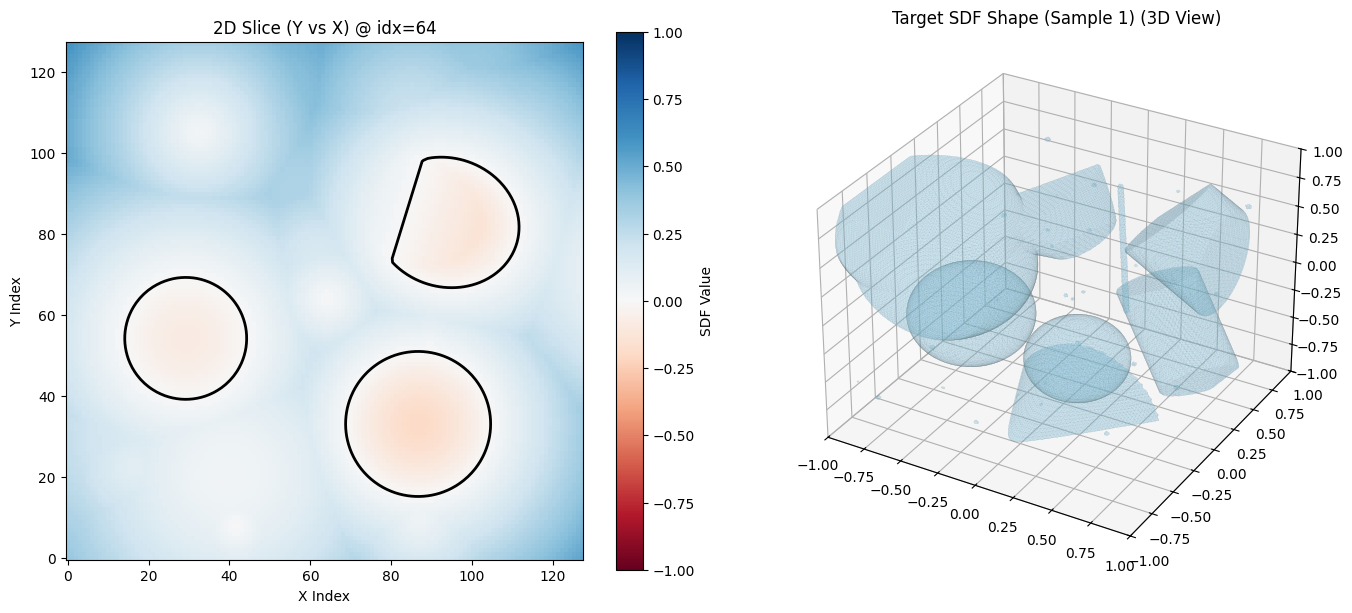


[2] 입력(Input) m_c 특징 공간 시각화


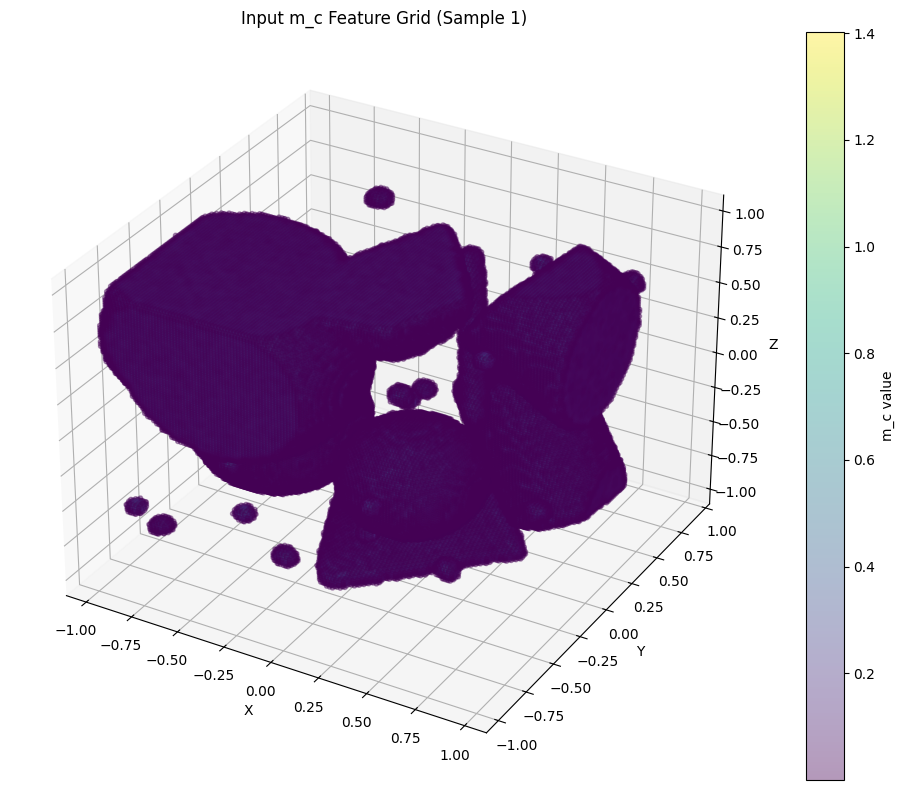

In [7]:
import numpy as np
import torch
from modules.config import config
from modules.visualizer import visualize_simulation, visualize_feature_grid,visualize_particles_and_features

# 1. 확인할 데이터 인덱스 설정 (0 ~ 4)
sample_idx =1
sdf_file = f"dataset4/sdf_grid_{sample_idx:03d}.npy"
mc_file = f"dataset4/mc_grid_{sample_idx:03d}.npy"

# 2. 데이터 로드 완료
sdf_grid = np.load(sdf_file)
mc_grid = np.load(mc_file)
print(f"📥 SDF 데이터 로드: {sdf_file} (Shape: {sdf_grid.shape})")
print(f"📥 m_c 데이터 로드: {mc_file} (Shape: {mc_grid.shape})")

# 3. [시각화 1] Target SDF (원본 3D 지오메트리 형태)
print("\n[1] 정답(Target) SDF 형상 시각화")
visualize_simulation(
    sdf_grid=sdf_grid, 
    domain_size=config.domain_size, 
    title=f"Target SDF Shape (Sample {sample_idx})"
)

# 4. [시각화 2] Input 3D CNN Features (파티클로부터 밀도 단위로 추출된 m_c 값)
print("\n[2] 입력(Input) m_c 특징 공간 시각화")

fig2 = visualize_feature_grid(
    m_c_grid=mc_grid,         # 앞서 파이프라인에서 나온 mc_grid 텐서 그대로 삽입
    grid_nodes=grid_nodes,    # 앞서 파이프라인에서 나온 grid_nodes 텐서 그대로 삽입
    title=f"Input m_c Feature Grid (Sample {sample_idx})"
)

In [ ]:
# 1. 기존 Config 설정값 기준
domain_size = config.domain_size
resolution = config.resolution

min_bound = -domain_size / 2.0  # -1.0
max_bound = domain_size / 2.0   # 1.0

# 2. X, Y, Z 축 각각에 대해 -1.0 부터 1.0 까지 64등분한 좌표점 생성
axis_coords = torch.linspace(min_bound, max_bound, resolution)

# 3. 3차원 공간(Meshgrid)으로 확장하여 (64, 64, 64, 3) 형태의 텐서 생성
X, Y, Z = torch.meshgrid(axis_coords, axis_coords, axis_coords, indexing='ij')

# 4. 좌표들을 하나로 묶고 (262144, 3) 형태로 평탄화(Flatten)
grid_nodes = torch.stack([X, Y, Z], dim=-1).reshape(-1, 3)

print(f"✅ 복구된 grid_nodes 형태: {grid_nodes.shape}")

## 3. sdf 계산 -CNN 학습

### 3.1 전처리 단계: 그리드 특징값(m_c) 계산

### 3.2 m_c 값 시각화

In [139]:
import torch
import numpy as np
import os
# 1. 모듈 임포트
from modules.config import config
from modules.sdf_generator import SDFGenerator
from modules.particle_sampler import sample_particles_poisson
from modules.sdf_network import FeatureConstruction
from modules.visualizer import visualize_simulation, visualize_particles_and_features

# ==========================================
# Setup: Config & 디바이스 초기화
# ==========================================
print(f"⚙️ Config 설정: Domain Size={config.domain_size}, Resolution={config.resolution}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ==========================================
# Phase 1: SDF 도형 생성 및 래스터라이징
# ==========================================
print("\n[Phase 1] 🎲 랜덤 SDF 도형 생성 중...")
# 새로 만든 OOP 클래스를 사용합니다.
generator = SDFGenerator(config)

random_sdf = generator.create_sample_shape() 
sdf_grid = generator.to_grid(random_sdf)

print(f"✅ SDF Grid 생성 완료: Shape={sdf_grid.shape}")

# ==========================================
# Phase 2: Poisson Disk 샘플링
# ==========================================
print("\n[Phase 2] 🎯 파티클 샘플링 중...")
# config 객체를 두 번째 인자로 넘겨받도록 변경된 부분을 반영합니다.
particles = sample_particles_poisson(sdf_grid, config)

print(f"✅ 파티클 샘플링 완료: {len(particles)}개 생성됨 (목표: {config.num_particles}개)")

# ==========================================
# Phase 3: 특징 인코딩 (Feature Construction)
# ==========================================
print("\n[Phase 3] 🧠 모델 입력용 특징(m_c) 추출 중...")
# 함수형 형태를 유지한 원본 FeatureConstruction을 사용하되, dx는 config 참조
feature_constructor = FeatureConstruction(dx=config.dx, device=device)

particles_tensor = torch.tensor(particles, dtype=torch.float32, device=device)

# 파티클 위치 기반으로 동적 그리드 변환 
grid_nodes, m_c, grid_shape = feature_constructor(particles_tensor)
m_c_grid = m_c.reshape(grid_shape).cpu().numpy()

print(f"✅ 기하학적 특징 추출 완료")
print(f"   - Grid Shape: {grid_shape}")
print(f"   - m_c 통계: Min={m_c.min():.4f}, Max={m_c.max():.4f}")

# ==========================================
# Phase 4: 데이터 저장 (.npy)
# ==========================================
print("\n[Phase 4] 💾 생성된 데이터를 .npy 형식으로 저장 중...")

# 출력 폴더 생성 (선택 사항, 깔끔한 관리를 위해)
save_dir = "./"
os.makedirs(save_dir, exist_ok=True)

# 텐서로 남아있는 grid_nodes를 numpy로 변환
grid_nodes_np = grid_nodes.cpu().numpy() if isinstance(grid_nodes, torch.Tensor) else grid_nodes

# 각각 .npy 파일로 저장
np.save(os.path.join(save_dir, "sdf_grid_128.npy"), sdf_grid)
np.save(os.path.join(save_dir, "particles_128.npy"), particles)
np.save(os.path.join(save_dir, "mc_grid_128.npy"), m_c_grid)
# np.save(os.path.join(save_dir, "grid_nodes_64.npy"), grid_nodes_np)

print(f"✅ 모든 데이터 저장 완료! (저장 위치: ./{save_dir}/)")



⚙️ Config 설정: Domain Size=2.0, Resolution=128

[Phase 1] 🎲 랜덤 SDF 도형 생성 중...
✅ SDF Grid 생성 완료: Shape=(128, 128, 128)

[Phase 2] 🎯 파티클 샘플링 중...
   -> 도형 부피 비율: 17.0%
   -> 타겟 PPC: 3.0 / 고정된 반지름(r): 0.0093
   -> BB 비율: 43.3%
   -> 샘플링 실행
   -> 최종 생성된 파티클 수: 833801개
✅ 파티클 샘플링 완료: 833801개 생성됨 (목표: 40000개)

[Phase 3] 🧠 모델 입력용 특징(m_c) 추출 중...
✅ 기하학적 특징 추출 완료
   - Grid Shape: (128, 128, 128)
   - m_c 통계: Min=0.0000, Max=1.2382

[Phase 4] 💾 생성된 데이터를 .npy 형식으로 저장 중...
✅ 모든 데이터 저장 완료! (저장 위치: ././/)



[Phase 4] 📊 프로세스 검증용 데이터 시각화


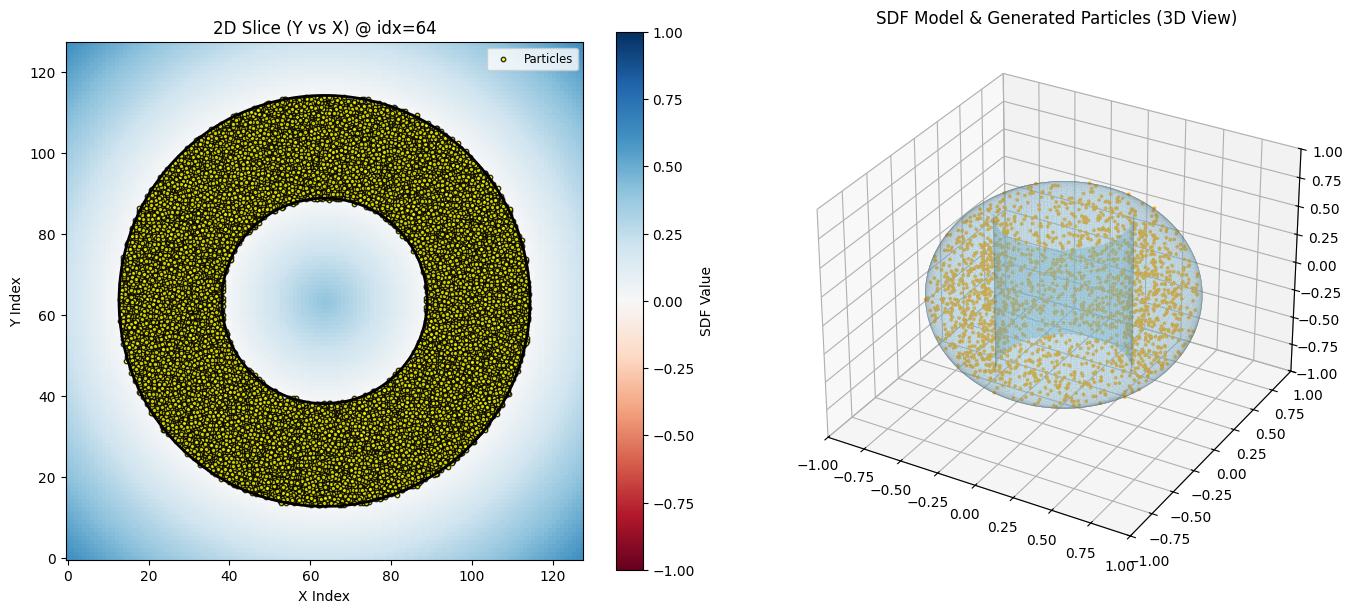

c:\Users\user00\Desktop\yubin\reconstruction\modules\visualizer.py:368: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


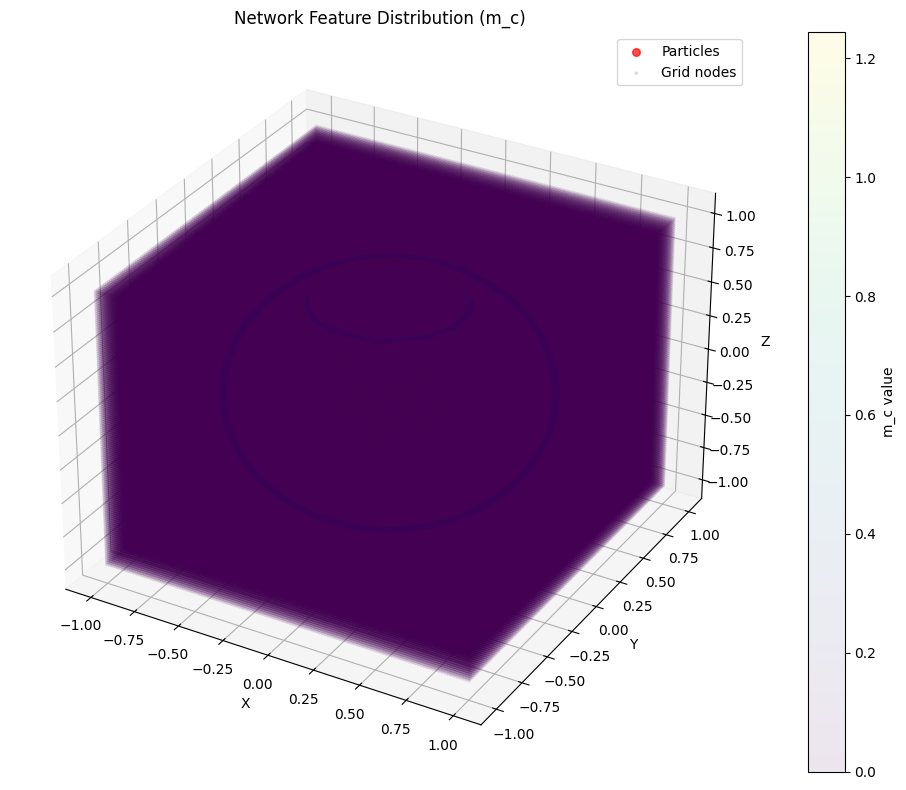

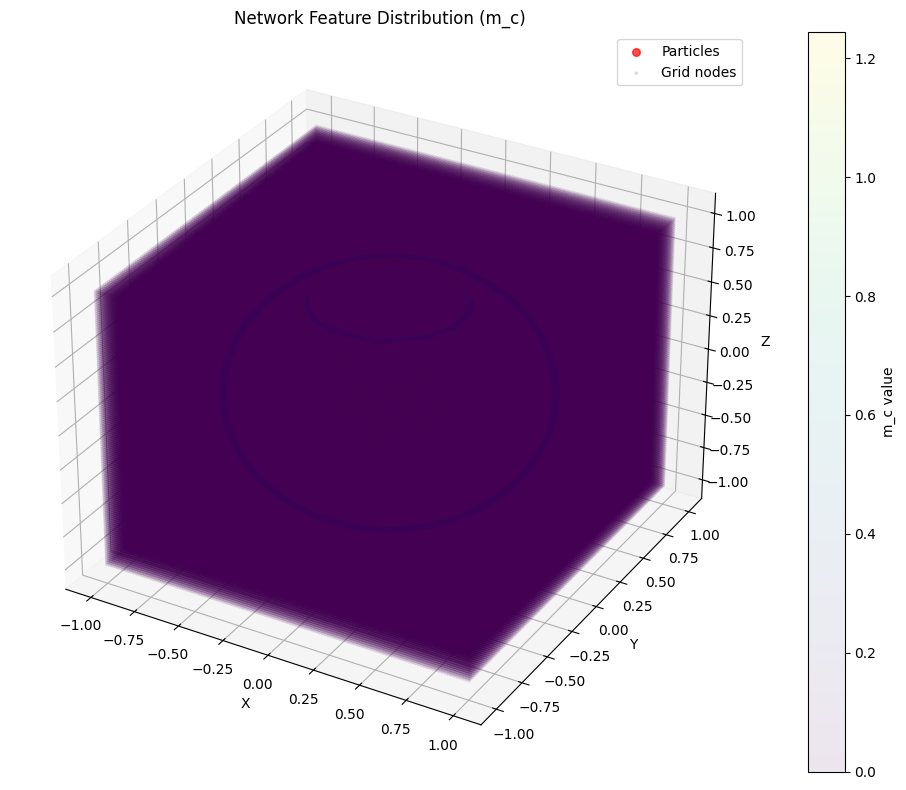

In [66]:

# ==========================================
# Phase 5: 시각화 모듈
# ==========================================
print("\n[Phase 4] 📊 프로세스 검증용 데이터 시각화")

# 4-1. 전반적인 형상 + 파티클 위치 뷰어
visualize_simulation(
    sdf_grid=sdf_grid, 
    particles=particles, 
    domain_size=config.domain_size, 
    title="SDF Model & Generated Particles"
)

# 4-2. 파티클 분포와 네트워크의 m_c 추출 결과 뷰어
visualize_particles_and_features(
    particles=particles_tensor.cpu(),
    grid_nodes=grid_nodes.cpu(),
    m_c_grid=m_c_grid,
    title="Network Feature Distribution (m_c)"
)

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from modules.config import config
from modules.particle_sampler import sample_particles_poisson
from modules.visualizer import visualize_simulation

print("=== 현재 디렉토리의 sdf_grid_64.npy 시각화 및 파티클 샘플링 ===")

# 1. 원본 SDF 데이터 불러오기
file_path = "sdf_grid_64.npy"
try:
    sdf_grid = np.load(file_path)
    print(f"✅ 데이터 로드 성공: {file_path} (Shape: {sdf_grid.shape})")
except FileNotFoundError:
    print(f"❌ 파일을 찾을 수 없습니다: {file_path}")
    sdf_grid = None
    
if sdf_grid is not None:
    # 2. 파티클 샘플링
    print("\n[파티클 샘플링 중...]")
    particles = sample_particles_poisson(sdf_grid, config)
    print(f"✅ 추출된 파티클 갯수: {len(particles)}")
    # 3. 파티클 위치 기반으로 동적 그리드 변환 및 m_c 계산
    print("\n[DirectML 가속으로 m_c 특징값 계산 중...]")
    feature_constructor = FeatureConstruction(dx=config.dx, device=device)
    particles_tensor = torch.tensor(particles, dtype=torch.float32, device=device)
    
    # 🌟 기존에 구현되어 있는 통합 함수 호출!
    grid_nodes, m_c, grid_shape = feature_constructor(particles_tensor)
    
    # 3D 텐서(64x64x64)로 복원 후 numpy 배열로 변환
    mc_grid = m_c.reshape(grid_shape).cpu().numpy()
    
    # 4. 결과 저장 (mc_grid_64.npy)
    save_path = "mc_grid_64.npy"
    # np.save(save_path, mc_grid)
    print(f"✅ m_c 그리드 저장 완료: {save_path} (Shape: {mc_grid.shape})")
    # 5. m_c 3D 특징 맵 시각화
    print("\n[m_c 특징 공간 시각화]")
    fig = visualize_feature_grid(
        m_c_grid=m_c,             # flatten된 1D 텐서 그대로 투입
        grid_nodes=grid_nodes,    # 짝이 완벽하게 맞는 3D 좌표 노드
        title="Computed m_c Feature Grid (from sdf_grid_64.npy)"
    )
    plt.show()

=== 현재 디렉토리의 sdf_grid_64.npy 시각화 및 파티클 샘플링 ===
✅ 데이터 로드 성공: sdf_grid_64.npy (Shape: (64, 64, 64))

[파티클 샘플링 중...]
   -> 도형 부피 비율: 16.6%
   -> 타겟 PPC: 3.0 / 고정된 반지름(r): 0.0093


KeyboardInterrupt: 

📥 m_c 데이터 로드: mc_grid.npy (Shape: (128, 128, 128))


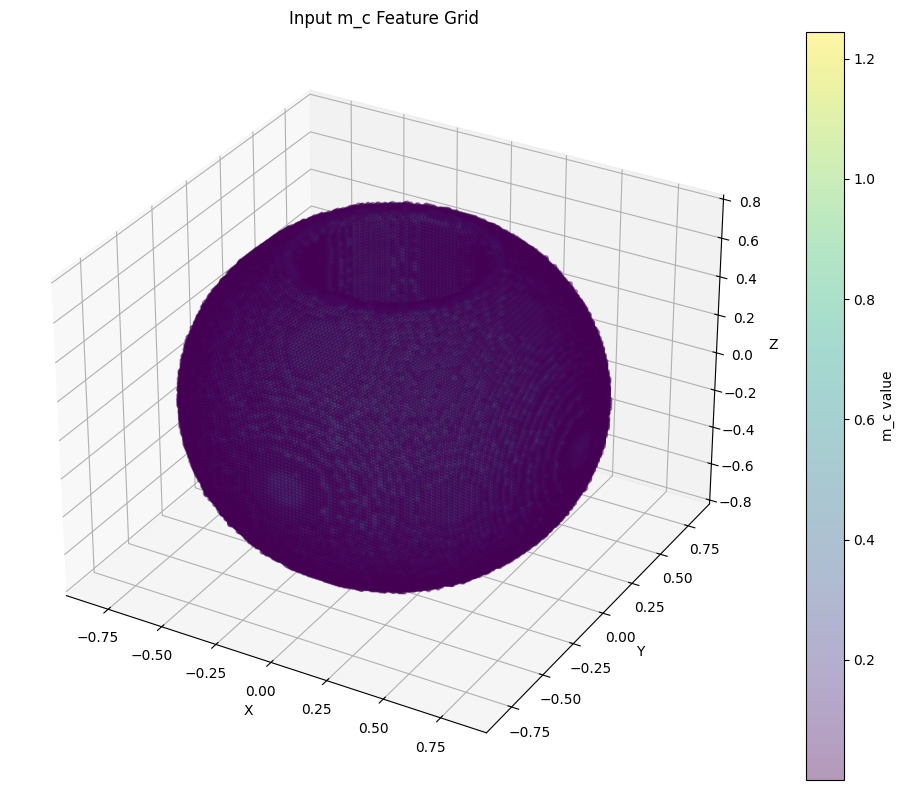

In [67]:
# 1. 확인할 데이터 인덱스 설정 (0 ~ 4)
sdf_file = f"sdf_grid.npy"
mc_file = f"mc_grid.npy"

# 2. 데이터 로드 완료
sdf_grid = np.load(sdf_file)
mc_grid = np.load(mc_file)
print(f"📥 m_c 데이터 로드: {mc_file} (Shape: {mc_grid.shape})")

fig2 = visualize_feature_grid(
    m_c_grid=mc_grid,         # 앞서 파이프라인에서 나온 mc_grid 텐서 그대로 삽입
    grid_nodes=grid_nodes,    # 앞서 파이프라인에서 나온 grid_nodes 텐서 그대로 삽입
    title=f"Input m_c Feature Grid"
)

### 3.3 3D CNN 네트워크를 통한 SDF 값 추론

### 3.4 학습

디바이스/데이터로더 설정 셀

In [97]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import time
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch.nn.functional as F

# 모듈 임포트는 유저님 환경에 맞게 유지
from modules.sdf_network import SDFNetwork
from modules.dataset import create_dataloader
from modules.sdf_network import PolynomialRegularizedSDFLoss

# ==========================================
# 🚨 1. DirectML 개입 원천 차단 및 순수 CPU 강제 고정
# ==========================================
# device = torch.device('cpu')
# print(f"🔒 현재 강제 고정된 디바이스: {device}")

# 2. 데이터로더 생성 (배치 사이즈는 메모리에 맞게 조절)
print("데이터를 불러옵니다...")
train_loader = create_dataloader(data_dir="dataset3", batch_size=256, in_memory=True)

# 3. 모델 및 옵티마이저 생성 (모델을 강제로 CPU로!)
model = SDFNetwork().to(device)
model.float() # 강제 float32 포맷팅
model.train()

optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = PolynomialRegularizedSDFLoss(lambda_reg=1.0).to(device)

데이터를 불러옵니다...
💾 데이터를 메모리에 캐싱 중입니다...
✅ 캐싱 완료.
🔍 표면 근처(Narrow Band: |SDF| <= 0.0156) 노드만 필터링 중...
✅ 필터링 완료: 전체 209715200개 중 핵심 5833744개만 학습합니다! (약 2.8%)


훈련 반복문 셀

In [86]:
num_epochs = 5
train_losses = []

start_time = time.time()

# 🚨 [추가] 전체 데이터의 10%만 보고 다음 에폭으로 넘어가도록 설정
max_batches_per_epoch = len(train_loader) // 2 

for epoch in range(num_epochs):
    running_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f"Epoch [{epoch+1:02d}/{num_epochs:02d}]")
    
    for batch_idx, (feature_patch, sdf_target) in enumerate(progress_bar):
        
        # 🚨 [추가] 지정된 배치 수(10%)에 도달하면 이번 에폭은 조기 종료!
        if batch_idx >= max_batches_per_epoch:
            break
            
        feature_patch = feature_patch.to(device, dtype=torch.float32)
        sdf_target = sdf_target.to(device, dtype=torch.float32)
        
        if feature_patch.dim() == 4:
            feature_patch = feature_patch.unsqueeze(1)
        
        pred_sdf = model(feature_patch)
        loss = criterion(pred_sdf, sdf_target)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * feature_patch.size(0)
        
        if batch_idx % 10 == 0:
            progress_bar.set_postfix({'loss': f"{loss.item():.5f}"})
            
    # 평균 Loss 계산 시 분모도 우리가 실제로 본 데이터 개수로 맞춰줍니다.
    actual_samples_seen = max_batches_per_epoch * train_loader.batch_size
    avg_loss = running_loss / actual_samples_seen
    train_losses.append(avg_loss)
    print(f"✅ Epoch {epoch+1} 완료! 최종 평균 Loss: {avg_loss:.6f}\n")

elapsed_time = time.time() - start_time
print(f"✅ 학습 완료! (총 소요 시간: {elapsed_time:.1f}초)")

Epoch [01/05]:  50%|████▉     | 11394/22789 [04:35<04:35, 41.29it/s, loss=0.03597]


✅ Epoch 1 완료! 최종 평균 Loss: 0.032804



Epoch [02/05]:  50%|████▉     | 11394/22789 [04:39<04:39, 40.80it/s, loss=0.03154]


✅ Epoch 2 완료! 최종 평균 Loss: 0.027939



Epoch [03/05]:  50%|████▉     | 11394/22789 [04:38<04:38, 40.96it/s, loss=0.02629]


✅ Epoch 3 완료! 최종 평균 Loss: 0.027607



Epoch [04/05]:  50%|████▉     | 11394/22789 [04:36<04:36, 41.25it/s, loss=0.03211]


✅ Epoch 4 완료! 최종 평균 Loss: 0.027376



Epoch [05/05]:  50%|████▉     | 11394/22789 [04:35<04:35, 41.36it/s, loss=0.03039]

✅ Epoch 5 완료! 최종 평균 Loss: 0.027267

✅ 학습 완료! (총 소요 시간: 1385.1초)


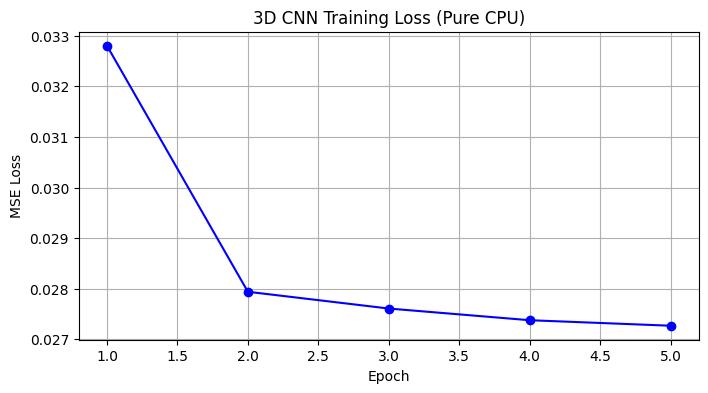

💾 CPU로 학습된 가중치가 안전하게 저장되었습니다!


In [138]:

# ==========================================
# 5. Loss 그래프 시각화
# ==========================================
plt.figure(figsize=(8, 4))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', linestyle='-', color='b')
plt.title("3D CNN Training Loss (Pure CPU)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

# 6. 소중한 가중치 저장
# torch.save(model.state_dict(), "sdf_network_cpu.pth")
print("💾 CPU로 학습된 가중치가 안전하게 저장되었습니다!")

In [ ]:
import time
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 사용자 정의 모듈 임포트 (경로는 본인 환경에 맞게 유지)
from modules.sdf_network import SDFNetwork, SDFReconstruction
from modules.config import config
from modules.visualizer import visualize_simulation

print("=== [Step 5] 저장된 가중치 불러오기 및 다이렉트 SDF 추론 ===")

# -------------------------------------------------------------------
# [핵심 수정 사항] 진짜 신경망 모델(SDFNetwork)을 불러옵니다!
# -------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. 빈 모델 껍데기(구조) 생성
model = SDFNetwork().to(device)

# 2. 가중치 파일 경로 및 로드
weights_path = "sdf_network_cpu.pth"
model.load_state_dict(torch.load(weights_path, map_location=device))

# 3. 평가(eval) 모드로 전환
model.eval()

print(f"✅ '{weights_path}' 가중치 로드 완료! (Device: {device})")


In [157]:
import time
import numpy as np
import torch
import torch.optim as optim
from tqdm import tqdm

# 🚨 유저님의 실제 모듈 구조에 맞춘 완벽한 임포트
from modules.dataset import SDFDataset
from modules.sdf_network import SDFNetwork, PolynomialRegularizedSDFLoss, SDFReconstruction
from modules.config import config
from modules.visualizer import visualize_simulation

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"⚡ 작동 디바이스: {device}")

# ==========================================
# 📦 1. 데이터 로드 (Narrow Band 적용)
# ==========================================
print("\n[데이터 로드 시작]")

# 🚨 메인 스크립트에서 내가 원하는 대로 직관적으로 세팅!
train_dataset = SDFDataset(
    data_dir="dataset3", 
    patch_size=8,
    in_memory=True, 
    use_narrow_band=True, 
    use_bg_sample=False,     # 스위치 켜고 끄기가 메인 코드에 바로 보임
    bg_sample_ratio=0.10
)

# 데이터로더로 포장
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=0)


⚡ 작동 디바이스: cuda

[데이터 로드 시작]
💾 데이터를 메모리에 캐싱 중입니다...
✅ 캐싱 완료.
🔍 [초고속 필터링] 표면(|SDF| <= 0.0312) 샘플링 중...
✅ 샘플링 완료!
   - 표면(Narrow Band) 데이터: 11635147개 (100% 사용)
   - 최종 학습 데이터: 11635147개 (전체 중 5.5%)


In [143]:

# 추론 및 시각화를 위한 평가용 데이터 로드
m_c_grid_np = np.load("sample/mc_grid.npy")
m_c_grid_tensor = torch.tensor(m_c_grid_np, dtype=torch.float32)
sdf_grid_gt = np.load("sample/sdf_grid.npy")  # 정답지 (비교용)

# 공통 학습 파라미터 세팅 (빠른 실험을 위해 데이터의 50%만 학습)
num_epochs = 5
max_batches = len(train_loader) #// 2

In [160]:

# ==========================================
# 🧪 [실험 1] 다항식 정규화(Polynomial) + MSE 모드 (논문 세팅)
# ==========================================
print("\n" + "="*55)
print(">> 🧪 [실험 1] 다항식 정규화(Poly) + MSE 모드 학습 시작")
print("="*55)

model_poly = SDFNetwork().to(device)
optimizer_poly = optim.Adam(model_poly.parameters(), lr=0.0002)
# 🚨 use_poly_loss=True (정규화 ON)
criterion_poly = PolynomialRegularizedSDFLoss(lambda_reg=1.0, use_poly_loss=True).to(device)

start_time = time.time()
model_poly.train_step(
    train_loader=train_loader,
    optimizer=optimizer_poly,
    criterion=criterion_poly,
    device=device,
    num_epochs=num_epochs,
    max_batches_per_epoch=max_batches
)
print(f"✅ 실험 1 학습 완료! (소요 시간: {time.time() - start_time:.1f}초)")


print(">> 실험 1 초고속 추론 중...")
reconstructor_poly = SDFReconstruction(dx=config.dx, device=device)
reconstructor_poly.network = model_poly  # 학습된 모델 장착
pred_sdf_poly = reconstructor_poly.inference(m_c_grid_tensor, patch_size=8, batch_size=2048)




>> 🧪 [실험 1] 다항식 정규화(Poly) + MSE 모드 학습 시작


Epoch [01/05]: 100%|██████████| 45450/45450 [18:53<00:00, 40.10it/s, loss=0.00002] 


✅ Epoch 1 완료! 평균 Loss: 0.000271



Epoch [02/05]: 100%|██████████| 45450/45450 [18:57<00:00, 39.97it/s, loss=0.00001] 


✅ Epoch 2 완료! 평균 Loss: 0.000012



...

✅ Epoch 3 완료! 평균 Loss: 0.000012



Epoch [04/05]: 100%|██████████| 45450/45450 [18:55<00:00, 40.03it/s, loss=0.00001] 


✅ Epoch 4 완료! 평균 Loss: 0.000011



Epoch [05/05]: 100%|██████████| 45450/45450 [18:51<00:00, 40.16it/s, loss=0.00001] 


✅ Epoch 5 완료! 평균 Loss: 0.000011

✅ 실험 1 학습 완료! (소요 시간: 5673.9초)
>> 실험 1 초고속 추론 중...


In [158]:
# ==========================================
# 🧪 [실험 2] 순수 MSE 모드 (정규화 제거 비교용)
# ==========================================
print("\n" + "="*55)
print(">> 🧪 [실험 2] 순수 MSE 모드 학습 시작 (Poly OFF)")
print("="*55)

# 🚨 이전 모델의 기억을 지우고 완전히 새로운 모델 생성
model_mse = SDFNetwork().to(device)
optimizer_mse = optim.Adam(model_mse.parameters(), lr=0.0002)
# 🚨 use_poly_loss=False (정규화 OFF)
criterion_mse = PolynomialRegularizedSDFLoss(use_poly_loss=False).to(device)

start_time = time.time()
model_mse.train_step(
    train_loader=train_loader,
    optimizer=optimizer_mse,
    criterion=criterion_mse,
    device=device,
    num_epochs=num_epochs,
    max_batches_per_epoch=max_batches
)
print(f"✅ 실험 2 학습 완료! (소요 시간: {time.time() - start_time:.1f}초)")

print(">> 실험 2 초고속 추론 중...")
reconstructor_mse = SDFReconstruction(dx=config.dx, device=device)
reconstructor_mse.network = model_mse  # 두 번째로 학습된 모델 장착
pred_sdf_mse = reconstructor_mse.inference(m_c_grid_tensor, patch_size=8, batch_size=2048)




>> 🧪 [실험 2] 순수 MSE 모드 학습 시작 (Poly OFF)


Epoch [01/05]: 100%|██████████| 45450/45450 [19:02<00:00, 39.80it/s, loss=0.00001] 


✅ Epoch 1 완료! 평균 Loss: 0.000033



Epoch [02/05]: 100%|██████████| 45450/45450 [18:42<00:00, 40.48it/s, loss=0.00001] 


✅ Epoch 2 완료! 평균 Loss: 0.000012



...

✅ Epoch 3 완료! 평균 Loss: 0.000011



Epoch [04/05]: 100%|██████████| 45450/45450 [18:44<00:00, 40.43it/s, loss=0.00001] 


✅ Epoch 4 완료! 평균 Loss: 0.000011



Epoch [05/05]: 100%|██████████| 45450/45450 [18:41<00:00, 40.54it/s, loss=0.00001] 


✅ Epoch 5 완료! 평균 Loss: 0.000011

✅ 실험 2 학습 완료! (소요 시간: 5631.6초)
>> 실험 2 초고속 추론 중...


In [31]:

# ==========================================
# 📊 최종 결과 시각화 및 비교
# ==========================================
print("\n=== [Step 6] 결과물 시각화 (Ablation 비교) ===")

# 1. 정답지 (도넛 모양)
visualize_simulation(sdf_grid=sdf_grid_gt, domain_size=config.domain_size, title="1. Ground Truth (Real SDF)")

# 2. 논문 세팅 결과 (매끄러운 곡면)
visualize_simulation(sdf_grid=pred_sdf_poly.cpu().numpy(), domain_size=config.domain_size, title="2. Polynomial + MSE (Smooth)")

# 3. 정규화 끈 결과 (쭈글쭈글한 표면)
visualize_simulation(sdf_grid=pred_sdf_mse.cpu().numpy(), domain_size=config.domain_size, title="3. Pure MSE Only (Jagged)")


=== [Step 6] 결과물 시각화 (Ablation 비교) ===


NameError: name 'sdf_grid_gt' is not defined


>> 🎯 특정 테스트 데이터(Shape 010) 추론 시작
>> Poly 모델(정규화 ON)로 Shape 010 추론 중...
>> MSE 모델(정규화 OFF)로 Shape 010 추론 중...

=== [Step 7] Shape 010 결과물 시각화 (Unseen Data Test) ===


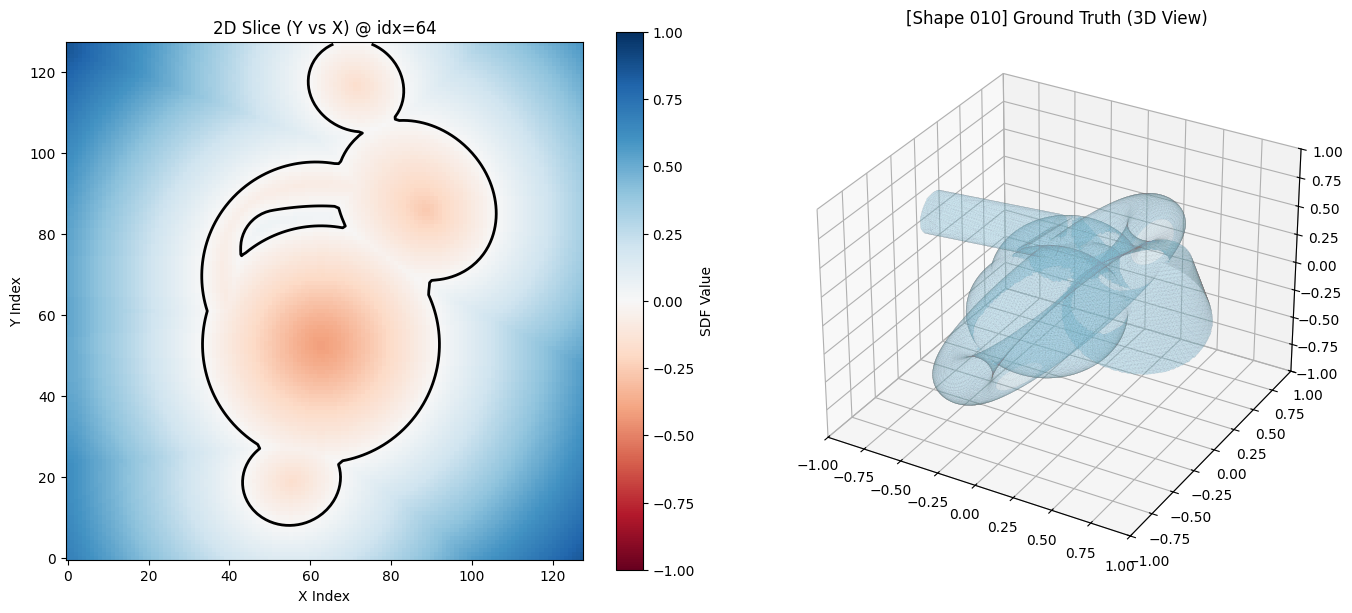

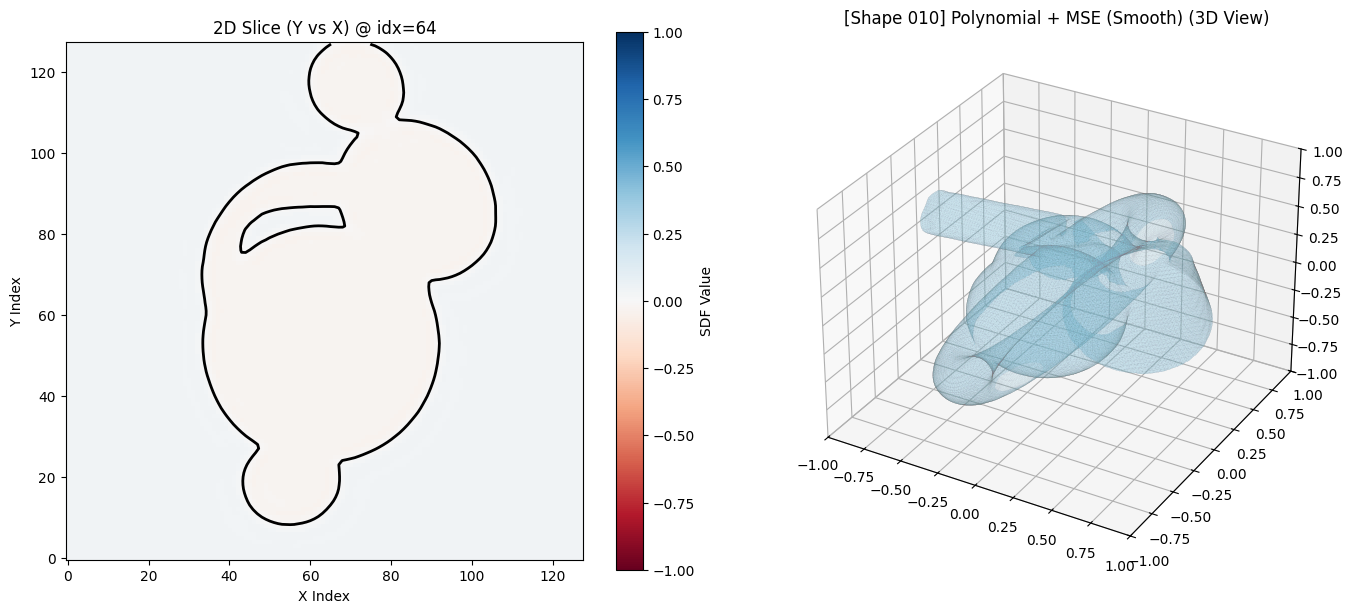

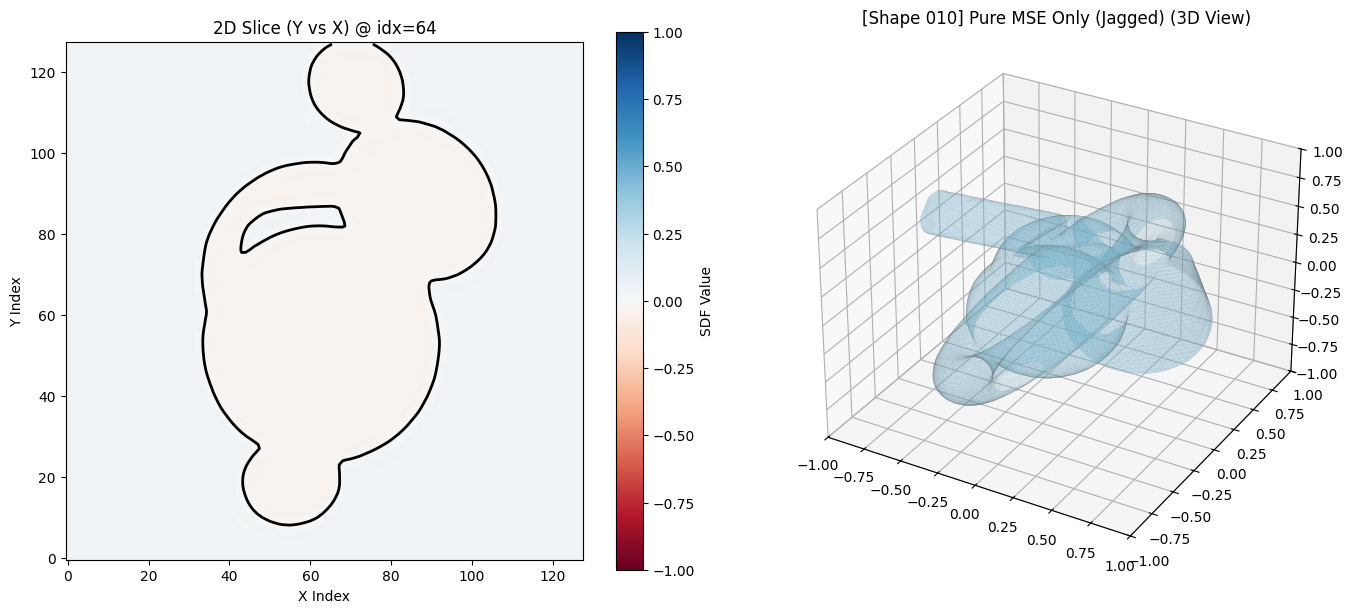

In [171]:
# ==========================================
# 🎯 [추가 실험] 특정 데이터 추론 및 비교
# ==========================================
# 🚨 여기서 원하는 데이터의 인덱스 번호만 바꾸면 끝입니다! (예: 1, 9, 10)
target_idx = 10  

# 0을 채워서 자동으로 3자리 문자열로 만듭니다. (예: 1 -> "001", 15 -> "015")
shape_name = f"{target_idx:03d}" 

print("\n" + "="*55)
print(f">> 🎯 특정 테스트 데이터(Shape {shape_name}) 추론 시작")
print("="*55)

# 1. 지정된 타겟 & 특징 그리드 로드 (전처리 완전 생략!)
# 파일 경로가 자동으로 세팅됩니다.
sdf_path = f"dataset3/sdf_grid_{shape_name}.npy"
mc_path = f"dataset3/mc_grid_{shape_name}.npy"

target_sdf = np.load(sdf_path)
m_c_grid_np = np.load(mc_path)

# 텐서 변환
m_c_grid_tensor = torch.tensor(m_c_grid_np, dtype=torch.float32)

# 2. [Poly 모드] 이미 학습된 Poly 모델로 초고속 추론
print(f">> Poly 모델(정규화 ON)로 Shape {shape_name} 추론 중...")
pred_sdf_poly = reconstructor_poly.inference(m_c_grid_tensor, patch_size=8, batch_size=2048)

# 3. [MSE 모드] 이미 학습된 MSE 모델로 초고속 추론
print(f">> MSE 모델(정규화 OFF)로 Shape {shape_name} 추론 중...")
pred_sdf_mse = reconstructor_mse.inference(m_c_grid_tensor, patch_size=8, batch_size=2048)

# ==========================================
# 📊 결과 시각화 및 비교
# ==========================================
print(f"\n=== [Step 7] Shape {shape_name} 결과물 시각화 (Unseen Data Test) ===")

# 1. 정답지 (진짜 모습)
visualize_simulation(
    sdf_grid=target_sdf, 
    domain_size=config.domain_size, 
    title=f"[Shape {shape_name}] Ground Truth"
)

# 2. 논문 세팅 결과 (정규화가 들어간 매끄러운 예측 결과)
visualize_simulation(
    sdf_grid=pred_sdf_poly.cpu().numpy(), 
    domain_size=config.domain_size, 
    title=f"[Shape {shape_name}] Polynomial + MSE (Smooth)"
)

# 3. 정규화 끈 결과 (정규화가 없을 때의 쭈글쭈글한 예측 결과)
visualize_simulation(
    sdf_grid=pred_sdf_mse.cpu().numpy(), 
    domain_size=config.domain_size, 
    title=f"[Shape {shape_name}] Pure MSE Only (Jagged)"
)

## 4. SDF 값 시각화 (최종 결과)

4.2 obj로 저장(mc 알고리즘)

In [75]:
from modules.visualizer import save_mesh_as_obj # 시각화용
save_mesh_as_obj(target_sdf, filename="train_shape_128.obj")
save_mesh_as_obj(pred_sdf_grid, filename="test_shape_128.obj")

✅ 메쉬 저장 완료: train_shape_128.obj (Vertices: 69408)
✅ 메쉬 저장 완료: test_shape_128.obj (Vertices: 73494)


In [172]:
from modules.visualizer import save_mesh_as_obj # 시각화용
save_mesh_as_obj(pred_sdf_poly.cpu().numpy(), filename="pred_sdf_poly.obj")
save_mesh_as_obj(pred_sdf_mse.cpu().numpy(), filename="pred_sdf_mse.obj")

✅ 메쉬 저장 완료: pred_sdf_poly.obj (Vertices: 67783)
✅ 메쉬 저장 완료: pred_sdf_mse.obj (Vertices: 68015)


npy 파일 이용한 sdf 시각화

In [ ]:
from modules.visualizer import visualize_npy
# 2. 데이터 시각화 (Phase 2)
print("\n--- Phase 2: 시각화 및 저장 ---")

# SDF 파일 확인
visualize_npy("sdf_grid_64.npy")

# 파티클 파일 확인
visualize_npy("particles.npy")


변수(객체) 이용한 시각화(런타임에 있는 메모리)

In [ ]:
from modules.visualizer import visualize_simulation

# SDF만 보기 (기존 plot_slice + 3D)
visualize_simulation(sdf_grid=sdf_grid)

# 파티클까지 겹쳐서 보기 (기존 plot_particles_and_sdf_slice + 3D)
visualize_simulation(sdf_grid=sdf_grid, particles=particles)

obj 인터랙티브 뷰어

In [135]:
from modules.visualizer import view_obj_interactive
# OBJ 파일 인터랙티브 뷰어
view_obj_interactive("train_shape.obj")

🖥️ 3D 뷰어 실행 중: train_shape.obj ...
✅ 뷰어 종료됨.


In [136]:
from modules.visualizer import view_obj_interactive
# OBJ 파일 인터랙티브 뷰어
view_obj_interactive("test_shape.obj")

🖥️ 3D 뷰어 실행 중: test_shape.obj ...
✅ 뷰어 종료됨.


In [15]:
from modules.visualizer import view_obj_interactive
# OBJ 파일 인터랙티브 뷰어
view_obj_interactive("pred_sdf_mse.obj")

🖥️ 3D 뷰어 실행 중: pred_sdf_mse.obj ...
✅ 뷰어 종료됨.
